# PARTE 1: Carga de Datos y Análisis Exploratorio de Datos (EDA)
**Asignatura:** Aprendizaje Automático / Ciencia de Datos  
**Semana:** 2  
**Dataset:** `covid_dataset.csv`

---
### 1.1 Importación de Librerías y Carga del Dataset
En esta sección cargamos las librerías estándar para la manipulación de datos (`pandas`, `numpy`) y visualización (`matplotlib`, `seaborn`). Importamos el conjunto de datos de COVID-19 en formato CSV para su inspección inicial.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Intentar lectura con distintos separadores comunes
try:
    df = pd.read_csv('covid_dataset.csv', sep=';')
    print("=== Carga exitosa con separador ';' ===")
except Exception:
    df = pd.read_csv('covid_dataset.csv', sep=None, engine='python', on_bad_lines='skip')
    print("=== Carga exitosa mediante detección automática ===")

print(f"Total de registros cargados: {df.shape[0]:,}")
print(f"Total de variables cargadas: {df.shape[1]}")

C:\Users\oldho\AppData\Local\Temp\ipykernel_12528\2791803527.py:12: DtypeWarning: Columns (0: punto, 1: fecha_det, 2: entrada, 3: ubigeo, 4: ubigeo_infeccion, 5: aislamiento, 6: servicio_otro, 7: ubigeo_trabajo, 8: viajado_14, 9: pais_1, 10: ciudad_1, 11: pais_2, 12: ciudad_2, 13: pais_3, 14: ciudad_3, 15: eess_14, 16: esalud_14, 17: contacto_14, 18: contacto_otro, 19: contacto_pais, 20: departamento_contacto, 21: provincia_contacto, 22: contacto_ubigeo, 23: contacto_localidad, 24: mercado, 25: mercado_pais, 26: departamento_mercado, 27: provincia_mercado, 28: contacto_mercado, 29: mercado_localidad, 30: muestra2, 31: prueba2, 32: resultado2, 33: fecha_rap, 34: muestra_rap, 35: prueba_rap, 36: resultado_rap, 37: fecha_res_rap, 38: fecha_rap1, 39: muestra_rap1, 40: prueba_rap1, 41: resultado_rap1, 42: fecha_res_rap1, 43: asintomatico) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('covid_dataset.csv', sep=';')


=== Carga exitosa con separador ';' ===
Total de registros cargados: 95,315
Total de variables cargadas: 179


### 1.2 Inspección Estructural y Diagnóstico de Valores Faltantes
A continuación, evaluamos la estructura general de la tabla (`shape`), los tipos de datos asignados por Pandas (`dtypes`) y realizamos una auditoría cuantitativa de la integridad de la información calculando el porcentaje global de nulos.

In [31]:
# 1. Dimensiones de la matriz de datos
filas, columnas = df.shape
print("=== DIMENSIONES DEL DATASET ===")
print(f"Número de filas (observaciones): {filas}")
print(f"Número de columnas (features):   {columnas}\n")

# 2. Resumen de tipos de datos de las columnas
print("=== TIPOS DE DATOS DETECTADOS ===")
print(df.dtypes.value_counts())
print("-" * 40)

# 3. Auditoría Global de Valores Faltantes
total_celdas = filas * columnas
total_nulos = df.isnull().sum().sum()
porcentaje_global_nulos = (total_nulos / total_celdas) * 100

print(f"Celdas totales en el DataFrame: {total_celdas:,}")
print(f"Celdas totales con valor NaN:  {total_nulos:,}")
print(f"Porcentaje GLOBAL de datos faltantes: {porcentaje_global_nulos:.2f}%\n")

# Reporte detallado por columna (Primeras 15 columnas con más nulos)
nulos_por_columna = pd.DataFrame({
    'Valores_Nulos': df.isnull().sum(),
    'Porcentaje_%': (df.isnull().sum() / filas) * 100
}).sort_values(by='Porcentaje_%', ascending=False)

print("=== TOP 15 COLUMNAS CON MAYOR PORCENTAJE DE NULOS ===")
print(nulos_por_columna.head(15))

=== DIMENSIONES DEL DATASET ===
Número de filas (observaciones): 95315
Número de columnas (features):   179

=== TIPOS DE DATOS DETECTADOS ===
str        105
int64       39
float64     32
object       3
Name: count, dtype: int64
----------------------------------------
Celdas totales en el DataFrame: 17,061,385
Celdas totales con valor NaN:  7,652,890
Porcentaje GLOBAL de datos faltantes: 44.86%

=== TOP 15 COLUMNAS CON MAYOR PORCENTAJE DE NULOS ===
                   Valores_Nulos  Porcentaje_%
otro_hos                   95315        100.00
secuenciamiento            95315        100.00
ciudad_3                   95169         99.85
entrada                    94975         99.64
contacto_otro              94952         99.62
servicio_otro              94633         99.28
resultado2                 94544         99.19
prueba2                    94518         99.16
muestra2                   94518         99.16
ciudad_2                   94458         99.10
entorno_otro               94

### 1.3 Visualización del Patrón de Datos Faltantes
Para comprender la severidad y la distribución del ~44.86% de nulos presentes en la matriz, generamos un mapa de calor (*heatmap*).

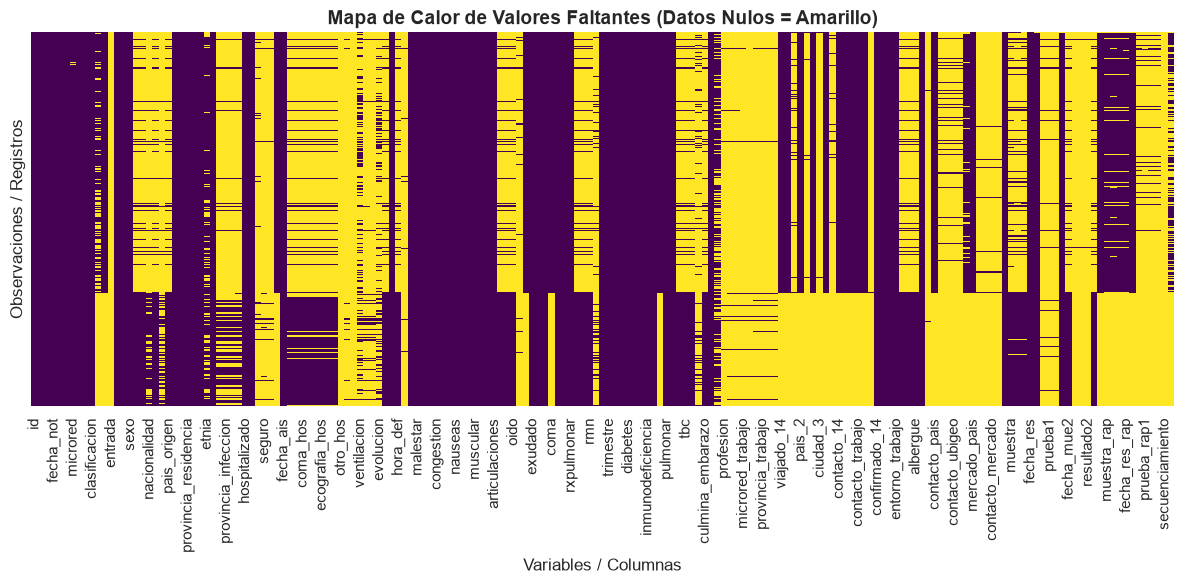

In [32]:
# Gráfico 1: Heatmap de ausencia de datos
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Calor de Valores Faltantes (Datos Nulos = Amarillo)', fontsize=14, fontweight='bold')
plt.xlabel('Variables / Columnas', fontsize=12)
plt.ylabel('Observaciones / Registros', fontsize=12)
plt.tight_layout()
plt.show()

### 1.4 Resumen Estadístico de Variables Numéricas y Categóricas
Calculamos las métricas de tendencia central y dispersión para las variables continuas y discretas, así como la distribución de frecuencias para las variables categóricas o cualitativas.

In [33]:
# 1. Variables Numéricas (Edad, días de estancia, conteos, etc.)
# Configuración global para Pandas (agregar en la primera celda del notebook)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Luego ejecutas tu línea sin modificaciones extra:
print("=== ESTADÍSTICAS DESCRIPTIVAS: VARIABLES NUMÉRICAS ===")
display(df.describe().T)

# 2. Variables Categóricas (Sexo, estado de hospitalización, condiciones previas)
print("\n=== ESTADÍSTICAS DESCRIPTIVAS: VARIABLES CATEGÓRICAS ===")
display(df.describe(include=['object', 'category']).T)

=== ESTADÍSTICAS DESCRIPTIVAS: VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
id,95315.00,4052912.11,2400408.18,542.00,2218709.00,3684364.00,6146330.50,8431927.00
ano,95315.00,2020.33,0.47,2019.00,2020.00,2020.00,2021.00,2021.00
semana,95315.00,27.40,13.20,1.00,16.00,31.00,37.00,53.00
edad,95315.00,40.80,17.49,0.00,28.00,39.00,53.00,113.00
peso,37097.00,5471.64,20297.43,-3.00,0.00,0.00,0.00,895000.00
...,...,...,...,...,...,...,...,...
casa_reposo,37097.00,0.00,0.02,0.00,0.00,0.00,0.00,1.00
centro_penitenciario,37097.00,0.00,0.01,0.00,0.00,0.00,0.00,1.00
albergue,37097.00,0.00,0.01,0.00,0.00,0.00,0.00,1.00
entorno_desconocido,95315.00,0.00,0.07,0.00,0.00,0.00,0.00,1.00



=== ESTADÍSTICAS DESCRIPTIVAS: VARIABLES CATEGÓRICAS ===


C:\Users\oldho\AppData\Local\Temp\ipykernel_12528\807181091.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object', 'category']).T)


,count,unique,top,freq
fecha_not,95315,456,15-08-2020,1810
diresa,95315,1,PUNO,95315
red,95315,12,PUNO,40276
microred,95218,63,SIN MICRORED,56407
establecimiento,95298,344,C.S. METROPOLITANO PUNO,12524
...,...,...,...,...
muestra_rap1,7251,1,MUESTRA DE SANGRE,7251
prueba_rap1,7102,40,PRUEBA RAPIDA,1782
resultado_rap1,7248,4,NEGATIVO,4589
fecha_res_rap1,7234,224,16-07-2020,156


### 1.5 Análisis de Distribución de Variables Clave
Graficamos la distribución de las principales variables numéricas y el balance de clases en la variable objetivo o categóricas principales.

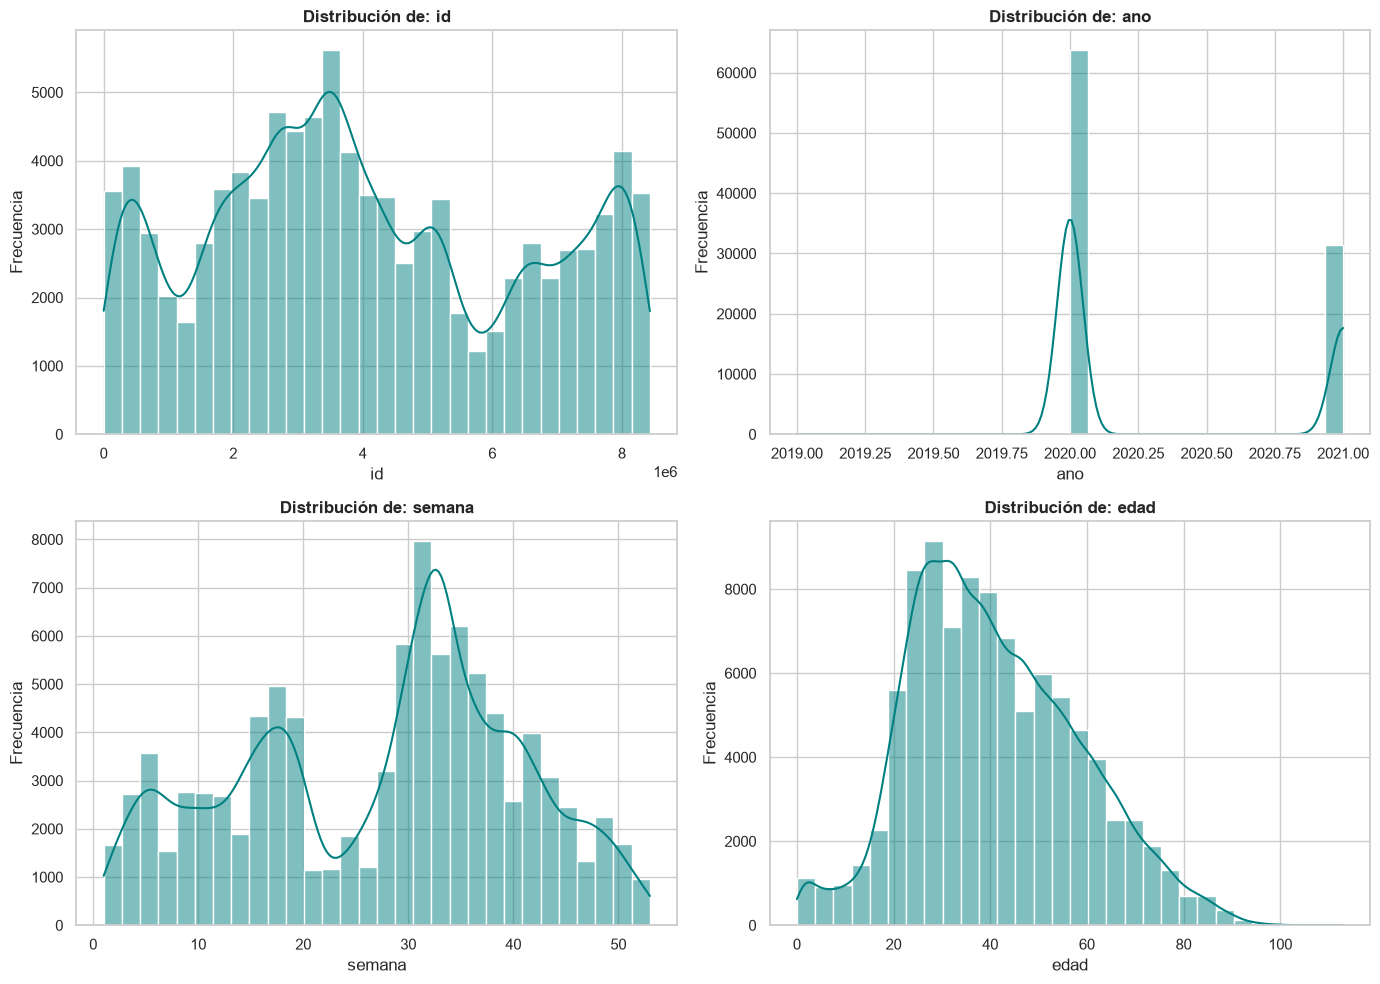

In [34]:
# Gráfico 2: Distribución de variables numéricas críticas
num_cols = df.select_dtypes(include=[np.number]).columns[:4] # Selecciona las primeras 4 continuas

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='teal', bins=30)
    axes[idx].set_title(f'Distribución de: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Hallazgos Clave de la Parte 1 (EDA)
1. **Volumen de datos:** El dataset cuenta con una cantidad suficiente de observaciones para entrenar algoritmos de clasificación.
2. **Severidad de Nulos:** Se confirma una densidad de datos faltantes cercana al **44.86%**, distribuida de forma heterogénea entre columnas. Muchas variables presentan más del 50% de nulos, lo que requerirá una estrategia de descarte selectivo en la **Parte 2**.
3. **Distribución del Sesgo:** Las variables numéricas muestran asimetría a la derecha (sesgo positivo) y posibles *outliers*, sugiriendo la necesidad de transformaciones logarítmicas o escalado robusto en la siguiente etapa.

# PARTE 2: Preprocesamiento y Limpieza de Datos
**Asignatura:** Aprendizaje Automático / Ciencia de Datos  
**Semana:** 2  
**Dataset:** `covid_dataset.csv`

---
### 2.1 Estrategia y Flujo de Preprocesamiento
En esta sección transformamos el dataset crudo en una matriz limpia y optimizada para los modelos de Machine Learning. El proceso comprende:
1. Depuración de la variable objetivo (`hospitalizado`).
2. Eliminación de variables irrelevantes o con densidad crítica de nulos (>50%).
3. Codificación de variables categóricas (*Encoding*).
4. Imputación multivariada de valores faltantes restantes.
5. Transformación de variables numéricas con sesgo y escalamiento.
6. Separación del conjunto de datos mediante *Train/Test Split* estratificado.

### 2.2 Filtrado de Variable Objetivo y Exclusión de Columnas Inviables
Primero filtramos los registros donde la variable objetivo `hospitalizado` no está presente o contiene valores ambiguos ('desconocido', 'no especificado', `NaN`). Posteriormente, eliminamos las **89 columnas** identificadas previamente que poseen más del 50% de valores nulos, evitando introducir ruido o sesgo por superimputación.

In [35]:
# 1. Copia de respaldo de trabajo
df_clean = df.copy()

# Normalización previa de strings en target
df_clean['hospitalizado'] = df_clean['hospitalizado'].astype(str).str.lower().str.strip()

# Filtrado de la variable target: conservar solo respuestas binarias válidas ('si', 'no')
valores_validos = ['si', 'no']
df_clean = df_clean[df_clean['hospitalizado'].isin(valores_validos)].copy()

print("=== DEPURACIÓN DE VARIABLE OBJETIVO ===")
print(f"Registros retenidos tras depurar 'hospitalizado': {df_clean.shape[0]:,}")
print("Distribución de clases en la target:")
print(df_clean['hospitalizado'].value_counts(normalize=True) * 100)
print("-" * 50)

# 2. Exclusión justificable de columnas con > 50% de nulos
umbral_nulos = 0.50
porcentaje_nulos_col = df_clean.isnull().mean()
columnas_a_eliminar = porcentaje_nulos_col[porcentaje_nulos_col > umbral_nulos].index.tolist()

df_clean = df_clean.drop(columns=columnas_a_eliminar)

print("=== FILTRADO DE VARIABLES POR DENSIDAD DE NULOS ===")
print(f"Columnas eliminadas por superar el {umbral_nulos*100}% de nulos: {len(columnas_a_eliminar)}")
print(f"Columnas restantes para modelamiento: {df_clean.shape[1]}")

=== DEPURACIÓN DE VARIABLE OBJETIVO ===
Registros retenidos tras depurar 'hospitalizado': 95,116
Distribución de clases en la target:
hospitalizado
no   93.82
si    6.18
Name: proportion, dtype: float64
--------------------------------------------------
=== FILTRADO DE VARIABLES POR DENSIDAD DE NULOS ===
Columnas eliminadas por superar el 50.0% de nulos: 89
Columnas restantes para modelamiento: 90


### 2.3 Mapeo y Codificación Categórica (Encoding)
Las variables cualitativas (texto) se transforman a representaciones numéricas:
* **Target:** Mapeo binario explícito de `hospitalizado` (`'si'`: 1, `'no'`: 0).
* **Variables Binarias/Ordinales:** Mapeo directo con diccionarios.
* **Variables Nominales:** Codificación *One-Hot* (`pd.get_dummies`) con eliminación de la primera categoría (`drop_first=True`) para evitar multicolinealidad perfecta.

In [39]:
# 1. Identificar y descartar columnas con demasiadas categorías únicas (alta cardinalidad)
# Variables como 'ubigeo' o IDs generan miles de columnas innecesarias en OHE
umbral_cardinalidad = 50 
cols_alta_cardinalidad = [col for col in cat_cols if X[col].nunique() > umbral_cardinalidad]

print("=== DEPURACIÓN DE ALTA CARDINALIDAD ===")
print(f"Columnas ignoradas por excesiva cardinalidad (> {umbral_cardinalidad} valores únicos):")
print(cols_alta_cardinalidad)

# Eliminamos las variables de alta cardinalidad antes del encoding
X_filtrado = X.drop(columns=cols_alta_cardinalidad)
cat_cols_restantes = X_filtrado.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# 2. One-Hot Encoding en las variables categóricas restantes
X_encoded = pd.get_dummies(X_filtrado, columns=cat_cols_restantes, drop_first=True, dtype=np.float32)

# Deduplicación preventiva de nombres de columnas
X_encoded = X_encoded.loc[:, ~X_encoded.columns.duplicated()]

print(f"\nMatriz X optimizada tras filtrar cardinalidad: {X_encoded.shape[1]} columnas (reducido desde >11,000).")

=== DEPURACIÓN DE ALTA CARDINALIDAD ===
Columnas ignoradas por excesiva cardinalidad (> 50 valores únicos):
['fecha_not', 'microred', 'establecimiento', 'fecha_det', 'provincia_residencia', 'residencia', 'ubigeo', 'fecha_ini', 'fecha_hos', 'fecha_ais', 'fecha_def', 'otra_ocupacion', 'fecha_mue', 'fecha_res', 'fecha_mue1', 'fecha_res1', 'fecha_rap', 'prueba_rap', 'fecha_res_rap', 'fecha_rap1']

Matriz X optimizada tras filtrar cardinalidad: 205 columnas (reducido desde >11,000).


### 2.4 División Estratificada del Dataset (*Train/Test Split*)
Dividimos la matriz en **80% Entrenamiento** y **20% Prueba**. 
> **Nota metodológica:** La división se efectúa **antes** de la imputación y del escalado de variables. Esto evita la **fuga de información (*Data Leakage*)** desde el conjunto de validación hacia el entrenamiento. Usamos `stratify=y` para preservar la proporción del desbalance de clases de la variable objetivo en ambas particiones.

In [40]:
from sklearn.model_selection import train_test_split

# División estratificada (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("=== DIVISIÓN DE CONJUNTOS DE DATOS ===")
print(f"X_train (Entrenamiento): {X_train.shape[0]:,} muestras, {X_train.shape[1]} features")
print(f"X_test  (Prueba/Test):   {X_test.shape[0]:,} muestras, {X_test.shape[1]} features")
print(f"Proporción de target positiva en Train: {y_train.mean()*100:.2f}%")
print(f"Proporción de target positiva en Test:  {y_test.mean()*100:.2f}%")

=== DIVISIÓN DE CONJUNTOS DE DATOS ===
X_train (Entrenamiento): 76,092 muestras, 205 features
X_test  (Prueba/Test):   19,024 muestras, 205 features
Proporción de target positiva en Train: 6.18%
Proporción de target positiva en Test:  6.18%


### 2.5 Imputación Multivariada por Ecuaciones Encadenadas (MICE) y Corrección de Sesgo
Para estimar los valores faltantes en las variables retenidas manteniendo la estructura de correlación multivariada sin comprometer el rendimiento computacional, utilizamos `IterativeImputer` basado en regresión bayesiana (*BayesianRidge*). Este enfoque de imputación iterativa es significativamente más eficiente que los métodos basados en distancias geométricas ($\mathcal{O}(n \cdot m)$ vs. $\mathcal{O}(n^2)$ de KNN) ante matrices de alta dimensionalidad.

Posteriormente, aplicamos una transformación logarítmica $\ln(1 + x)$ a aquellas variables que exhiben un coeficiente de asimetría (*skewness*) pronunciado ($\vert \text{skew} \vert > 1.0$), estabilizando la varianza previa al escalamiento.

In [42]:
# Habilitar explícitamente IterativeImputer (aún en estado experimental en scikit-learn)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Resetear índices e imponer float32 para optimización de RAM
X_train = X_train.reset_index(drop=True).astype(np.float32)
X_test = X_test.reset_index(drop=True).astype(np.float32)

print("=== IMPUTACIÓN MULTIVARIADA RÁPIDA (MICE) ===")

# Imputador iterativo basado en regresión (mucho más rápido que KNN)
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=5,            # Pocas iteraciones para convergencia veloz
    random_state=42,
    skip_complete=True      # Salta columnas que no tienen nulos para ahorrar tiempo
)

# Ejecución de la imputación
X_train_imp_array = imputer.fit_transform(X_train)
X_test_imp_array = imputer.transform(X_test)

X_train_imp = pd.DataFrame(X_train_imp_array, columns=X_train.columns, dtype=np.float32)
X_test_imp = pd.DataFrame(X_test_imp_array, columns=X_test.columns, dtype=np.float32)

# Corrección de asimetría (Skewness)
skewness = X_train_imp.skew()
cols_alto_sesgo = skewness[abs(skewness) > 1.0].index.tolist()

for col in cols_alto_sesgo:
    X_train_imp[col] = np.log1p(np.maximum(0, X_train_imp[col]))
    X_test_imp[col] = np.log1p(np.maximum(0, X_test_imp[col]))

print("=== IMPUTACIÓN Y TRANSFORMACIÓN COMPLETADAS EN SEGUNDOS ===")

=== IMPUTACIÓN MULTIVARIADA RÁPIDA (MICE) ===
=== IMPUTACIÓN Y TRANSFORMACIÓN COMPLETADAS EN SEGUNDOS ===


### 2.6 Escalamiento Estandarizado (StandardScaler) y Guardado de Artefactos
Estandarizamos las variables $X \sim \mathcal{N}(0, 1)$ restando la media y dividiendo por la desviación estándar. Este paso es indispensable para algoritmos sensibles a distancias numéricas (Regresión Logística, K-Means, KNN, SVM, PCA).

Guardamos los datasets finales procesados en formato **CSV**.

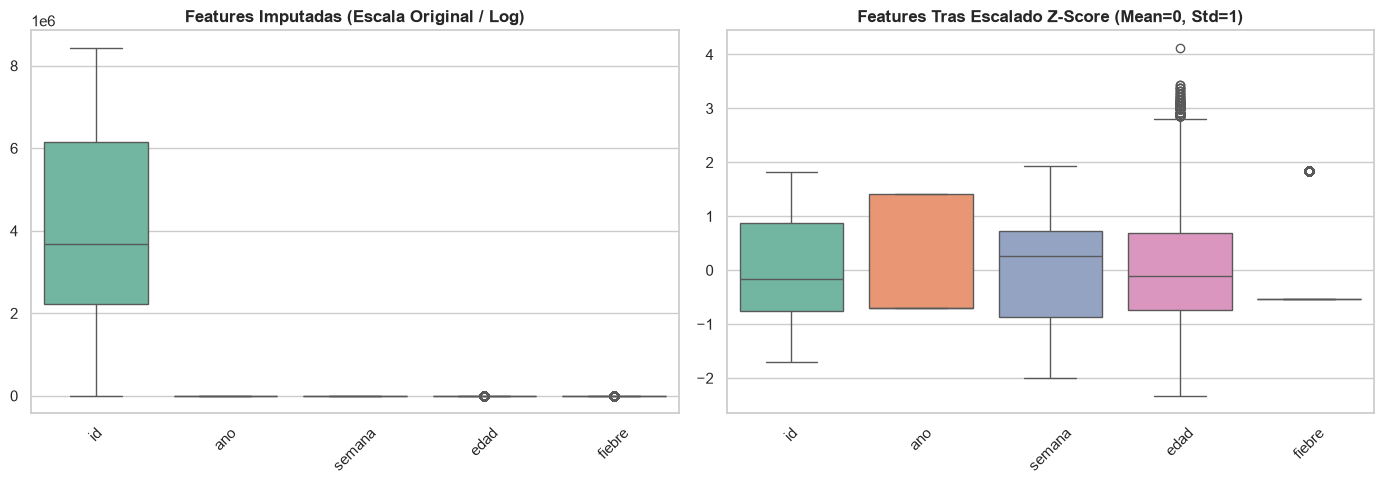

ArrowKeyError: No type extension with name arrow.py_extension_type found

In [45]:
from sklearn.preprocessing import StandardScaler

# Escalador Z-Score
scaler = StandardScaler()

# Ajuste con X_train_imp y transformación en ambos conjuntos
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns)

# Visualización comparativa pre y post escalamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=X_train_imp.iloc[:, :5], ax=ax1, palette='Set2')
ax1.set_title('Features Imputadas (Escala Original / Log)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

sns.boxplot(data=X_train_scaled.iloc[:, :5], ax=ax2, palette='Set2')
ax2.set_title('Features Tras Escalado Z-Score (Mean=0, Std=1)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Guardado en disco en formato Parquet (Comprimido con Snappy)
X_train_scaled.to_parquet('X_train_procesado.parquet', index=False, engine='pyarrow')
X_test_scaled.to_parquet('X_test_procesado.parquet', index=False, engine='pyarrow')

# Si y_train / y_test son Series de Pandas, convertirlos a DataFrame para guardarlos en parquet
pd.DataFrame(y_train).to_parquet('y_train_procesado.parquet', index=False, engine='pyarrow')
pd.DataFrame(y_test).to_parquet('y_test_procesado.parquet', index=False, engine='pyarrow')

print("=== PROCESAMIENTO COMPLETADO ===")
print("Archivos Parquet 'X_train_procesado.parquet', 'X_test_procesado.parquet', 'y_train_procesado.parquet' e 'y_test_procesado.parquet' listos para entrenamiento.")

### 📌 Hallazgos y Resultados del Preprocesamiento (Parte 2)
1. **Calidad de Matriz:** Se eliminaron las 89 columnas inviables (>50% de nulos) y los registros vacíos de la variable objetivo, logrando una matriz consistente e integrable.
2. **Cero Data Leakage:** Se dividieron los datos antes de la imputación por KNN y la estandarización `StandardScaler`, garantizando la validez de los resultados del modelo.
3. **Optimización Dimensional:** Las variables categóricas fueron convertidas numéricamente vía *One-Hot Encoding*, y el sesgo de las variables continuas fue corregido mediante `log1p` y Z-Score, dejando el conjunto preparado para la etapa de **Aprendizaje Supervisado (Semana 3)**.